<a href="https://colab.research.google.com/github/Wilson1994/melbourne-housing/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Melbourne Housing Snapshot


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [3]:
RAW_URL = "https://raw.githubusercontent.com/Wilson1994/melbourne-housing/refs/heads/main/data/melb_data.csv"

df = pd.read_csv(RAW_URL)

print(df.shape)

df.head()

(13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


##Крок 2. Перший огляд

In [4]:
print("Розмір таблиці:", df.shape)

df.head()

Розмір таблиці: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [5]:
print(df.dtypes)

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object


In [6]:
missing_percent = (df.isna().mean() * 100).round(2)

missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

BuildingArea     47.50
YearBuilt        39.58
CouncilArea      10.08
Car               0.46
Suburb            0.00
Price             0.00
Type              0.00
Rooms             0.00
Address           0.00
Distance          0.00
Method            0.00
Date              0.00
SellerG           0.00
Bathroom          0.00
Bedroom2          0.00
Postcode          0.00
Landsize          0.00
Lattitude         0.00
Longtitude        0.00
Regionname        0.00
Propertycount     0.00
dtype: float64


In [7]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


##Крок 3. Очищення


In [8]:
clean = df.copy()

In [9]:
if "Unnamed: 0" in clean.columns:
    clean = clean.drop(columns=["Unnamed: 0"])

In [10]:
clean["Date"] = pd.to_datetime(clean["Date"], dayfirst=True)

In [11]:
clean.loc[clean["Landsize"] == 0, "Landsize"] = np.nan
clean.loc[clean["BuildingArea"] == 0, "BuildingArea"] = np.nan

In [12]:
clean.loc[clean["YearBuilt"] < 1800, "YearBuilt"] = np.nan

In [13]:
print("Дублікатів:", clean.duplicated().sum())

clean = clean.drop_duplicates()

Дублікатів: 0


In [14]:
print("Розмір після очищення:", clean.shape)

Розмір після очищення: (13580, 21)


##Крок 4. Дослідження (EDA)


1. Розподіл ціни (гістограма)

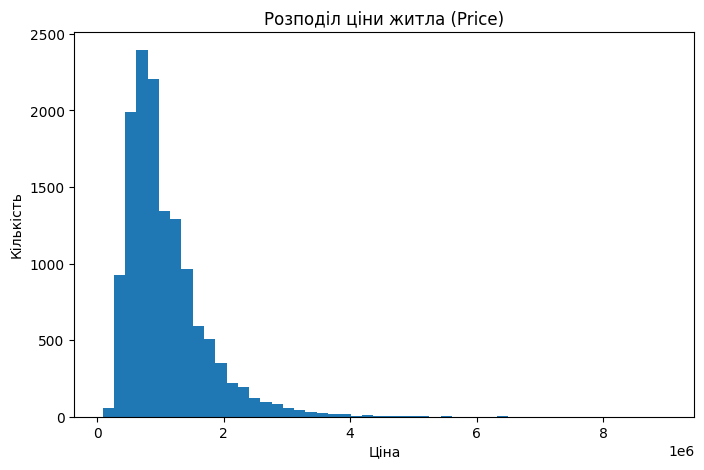

In [15]:
plt.figure(figsize=(8,5))
plt.hist(clean["Price"], bins=50)
plt.title("Розподіл ціни житла (Price)")
plt.xlabel("Ціна")
plt.ylabel("Кількість")
plt.show()

2. Гістограма логарифма ціни для порівняння

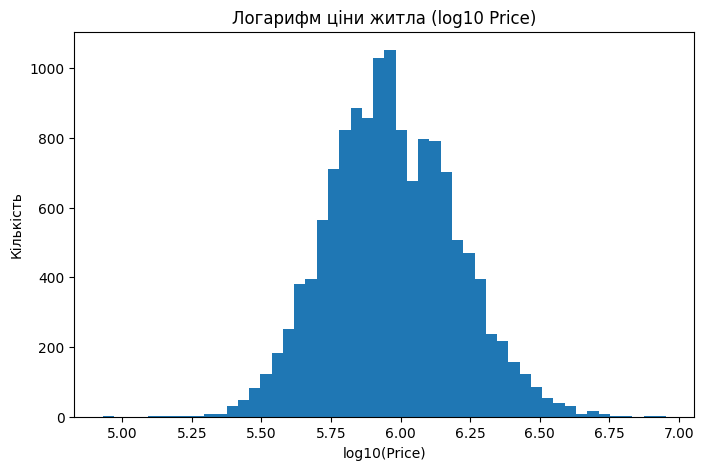

In [16]:
plt.figure(figsize=(8,5))
plt.hist(np.log10(clean["Price"]), bins=50)
plt.title("Логарифм ціни житла (log10 Price)")
plt.xlabel("log10(Price)")
plt.ylabel("Кількість")
plt.show()

3. Ціна за типом житла: boxplot

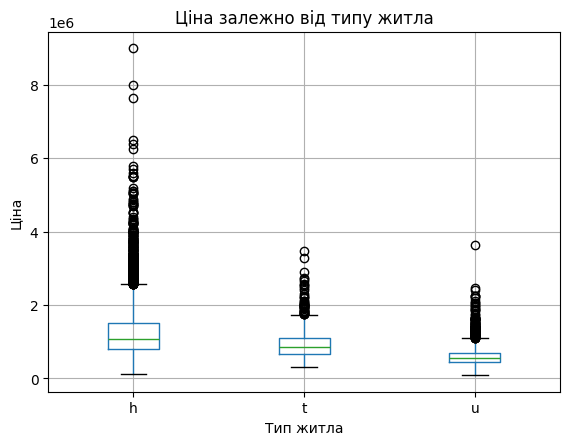

In [17]:
clean.boxplot(column="Price", by="Type")
plt.title("Ціна залежно від типу житла")
plt.suptitle("")
plt.xlabel("Тип житла")
plt.ylabel("Ціна")
plt.show()

4. кореляція числових ознак ІЗ ЦІНОЮ:

In [18]:
num = clean.select_dtypes("number")

corr_with_price = num.corr()["Price"].drop("Price")
corr_with_price = corr_with_price.reindex(corr_with_price.abs().sort_values(ascending=False).index)

print(corr_with_price)

Rooms            0.496634
Bedroom2         0.475951
Bathroom         0.467038
YearBuilt       -0.331828
Car              0.238979
Lattitude       -0.212934
Longtitude       0.203656
Distance        -0.162522
Postcode         0.107867
BuildingArea     0.091576
Propertycount   -0.042153
Landsize         0.023258
Name: Price, dtype: float64


5. пошук майже-дублікатів: подивіться на повну матрицю кореляцій

In [19]:
corr_matrix = num.corr().round(2)
corr_matrix

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.00,0.50,0.29,0.06,0.94,0.59,0.41,0.00,0.12,-0.07,0.02,0.10,-0.08
Price,0.50,1.00,-0.16,0.11,0.48,0.47,0.24,0.02,0.09,-0.33,-0.21,0.20,-0.04
Distance,0.29,-0.16,1.00,0.43,0.30,0.13,0.26,0.01,0.10,0.25,-0.13,0.24,-0.05
Postcode,0.06,0.11,0.43,1.00,0.06,0.11,0.05,0.03,0.06,0.04,-0.41,0.45,0.06
Bedroom2,0.94,0.48,0.30,0.06,1.00,0.58,0.41,0.00,0.12,-0.05,0.02,0.10,-0.08
Bathroom,0.59,0.47,0.13,0.11,0.58,1.00,0.32,0.03,0.11,0.15,-0.07,0.12,-0.05
Car,0.41,0.24,0.26,0.05,0.41,0.32,1.00,0.02,0.10,0.11,-0.00,0.06,-0.02
Landsize,0.00,0.02,0.01,0.03,0.00,0.03,0.02,1.00,0.50,0.08,0.01,0.01,-0.00
BuildingArea,0.12,0.09,0.10,0.06,0.12,0.11,0.10,0.50,1.00,0.02,0.04,-0.02,-0.03
YearBuilt,-0.07,-0.33,0.25,0.04,-0.05,0.15,0.11,0.08,0.02,1.00,0.06,-0.00,0.01


In [20]:
print(clean[["Rooms", "Bedroom2"]].corr())

            Rooms  Bedroom2
Rooms     1.00000   0.94419
Bedroom2  0.94419   1.00000


Вывод: Распределение цены сильно скошено вправо, что означает наличие большого количества дешёвых объектов и небольшого числа очень дорогих. Логарифмирование цены делает распределение более равномерным. Наиболее высокие цены наблюдаются у типа жилья house, тогда как units являются значительно более дешёвыми. Наиболее сильная связь с ценой наблюдается у площади дома, количества комнат и расстояния до центра города. Признаки Rooms и Bedroom2 имеют очень высокую корреляцию, что указывает на их дублирование.